# Quantum Machine Learning for the Barotropic Vorticity Equation

Reproduction of **Jaderberg, Gentile, Ghosh, Elfving, Jones, Vinci, Iorio, Roebber — 2024**
([arXiv:2404.08737](https://arxiv.org/pdf/2404.08737)) using **Qadence** (Pasqal).

The paper trains a Quantum Neural Network (QNN) on the **Barotropic Vorticity Equation
(BVE)** with ERA5 reanalysis data (15 July 1980).

Two experiments:

| | Experiment 1 (Supervised) | Experiment 2 (DQC / Physics-Informed) |
|---|---|---|
| Qubits N | 6 | 4 |
| HEA layers ℓ | 32 | 4 |
| Feature map | Serial TFFM (Ry, 4 features) | Serial TFFM (Ry, 4 features) |
| Optimiser | Adam, lr = 1e-2 | Adam, lr = 1e-2 |
| Loss | MSE(ψ_pred, ψ_data) | α₁·MSE(data) + α₄·MSE(BVE residual) |

The features fed to the circuit are `(t, x, y, z)` after the mapping
`x = sin φ cos λ`, `y = sin φ sin λ`, `z = cos φ` (Eqs. 6–8).


## 0 — Environment setup

Install once (uncomment if needed):


In [ ]:
 !pip install qadence torch xarray netCDF4 matplotlib numpy
 # !pip install cdsapi  # only needed if you download real ERA5 data


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.5/297.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.3/506.3 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.6/122.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.

In [ ]:
!pip install "cdsapi>=0.7.7"

with open("/root/.cdsapirc", "w") as f:
    f.write("url: https://cds.climate.copernicus.eu/api\n")
    f.write("key: 5326580b-4c9e-4955-960a-860f1b501083\n")

import cdsapi
client = cdsapi.Client()

client.retrieve("reanalysis-era5-pressure-levels", {
    "product_type": "reanalysis",
    "variable": "geopotential",
    "pressure_level": "500",
    "year": "1980", "month": "07", "day": "15",
    "time": ["00:00","03:00","06:00","09:00","12:00","15:00","18:00","21:00"],
    "data_format": "netcdf",
}, "era5_july15_1980.nc")

2026-05-22 08:13:15,519 INFO Request ID is 66dcba7a-e1b9-4a4e-a1cd-89a6921ab7f2
INFO:ecmwf.datastores.legacy_client:Request ID is 66dcba7a-e1b9-4a4e-a1cd-89a6921ab7f2
2026-05-22 08:13:15,695 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-05-22 08:13:33,204 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-05-22 08:13:40,939 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


895e127d22f5646083fa2908ccbde6aa.nc:   0%|          | 0.00/9.62M [00:00<?, ?B/s]

'era5_july15_1980.nc'

In [ ]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda")  # quantum sims are gpu-friendly here
DTYPE = torch.float32          # AD on PDE residuals benefits from f32

print("Torch:", torch.__version__)


Torch: 2.10.0+cpu


In [ ]:
from qadence import (
    QNN,
    FeatureMapConfig,
    AnsatzConfig,
    ObservableConfig,
    AnsatzType,
    Strategy,
    BasisSet,
    ReuploadScaling,
    MultivariateStrategy,
    BackendName,
    DiffMode,
)
from qadence.operations import Z as ZGate # <-- gate class, not the numpy matrix
print("Qadence loaded.")


Qadence loaded.


## 1 — Load ERA5 data (15 July 1980)

The DLWP-CS tutorial you linked
([Tutorials/1 - Downloading and processing ERA5.ipynb](https://github.com/jweyn/DLWP-CS/blob/master/Tutorials/1%20-%20Downloading%20and%20processing%20ERA5.ipynb))
shows how to grab ERA5 NetCDF files via `cdsapi`.

For Jaderberg et al. (2024), the relevant fields on **15 July 1980** are the
500 hPa stream-function `ψ` (or equivalently the horizontal wind from which `ψ`
is derived) sampled every 3 hours.

To keep this notebook self-contained, we provide a **synthetic Rossby-Haurwitz
type stream function** as fallback so the training loops actually run end-to-end.
Replace this block with a real ERA5 NetCDF read once the file is on disk.


In [ ]:
def load_era5_or_synthetic(nc_path=None):
    """Return (psi, lat_deg, lon_deg, time_hours).
    psi has shape (T, n_lat, n_lon)."""
    if nc_path and os.path.exists(nc_path):
        import xarray as xr
        ds = xr.open_dataset(nc_path)
        # Adjust variable name to whatever your ERA5 file contains.
        var = "stream_function" if "stream_function" in ds else list(ds.data_vars)[0]
        psi = ds[var].values
        lat = ds["latitude"].values if "latitude" in ds else ds["lat"].values
        lon = ds["longitude"].values if "longitude" in ds else ds["lon"].values
        psi = np.squeeze(psi)              # supprime la dim pressure_level
        # downsample pour rester gérable
        psi = psi[:, ::16, ::16]
        lat = lat[::16]
        lon = lon[::16]
        # Build a "hours since first sample" axis from the time coord.
        time_var = "time" if "time" in ds else "valid_time"
        t_hours = (ds[time_var].values - ds[time_var].values[0]).astype("timedelta64[h]").astype(int)
        return psi.astype(np.float64), lat.astype(np.float64), lon.astype(np.float64), t_hours.astype(np.float64)

    # ---- Synthetic Rossby-Haurwitz wave (R-H wave number 4) ----
    # ψ(φ,λ,t) = -ω cos φ + K cos^4 φ sin(4λ - σ t)
    # φ here is *latitude* in radians; we'll convert to colatitude later.
    n_lat, n_lon, n_t = 16, 32, 8
    lat = np.linspace(-87.5, 87.5, n_lat)        # degrees
    lon = np.linspace(0.0, 360.0 - 360.0/n_lon, n_lon)
    t_hours = np.arange(n_t) * 3.0               # 0, 3, 6, ..., 21 h

    LAT, LON = np.meshgrid(np.deg2rad(lat), np.deg2rad(lon), indexing="ij")
    psi = np.zeros((n_t, n_lat, n_lon))
    omega = 7.292e-5
    K = 1.5e-7
    sigma = 5e-6
    for k, t in enumerate(t_hours * 3600.0):
        psi[k] = -omega * np.sin(LAT) + K * (np.cos(LAT) ** 4) * np.sin(4 * LON - sigma * t)
    return psi, lat, lon, t_hours

psi_raw, lat_deg, lon_deg, t_hours = load_era5_or_synthetic("era5_july15_1980.nc")
print("psi shape:", psi_raw.shape, "  lat:", lat_deg.shape,
      "  lon:", lon_deg.shape, "  t_hours:", t_hours)


psi shape: (8, 46, 90)   lat: (46,)   lon: (90,)   t_hours: [ 0.  3.  6.  9. 12. 15. 18. 21.]


## 2 — Coordinate mapping  (Eqs. 6–8 of the paper)

The paper feeds `(t, x, y, z)` to the quantum circuit, where

$$x = \sin\phi\,\cos\lambda,\quad y = \sin\phi\,\sin\lambda,\quad z = \cos\phi$$

with **φ the colatitude** (0 at the north pole, π at the south pole).
ERA5 stores latitude `lat_deg`, so we convert with `φ = π/2 − lat_rad`.


In [ ]:
def latlon_to_xyz(lat_deg_grid, lon_deg_grid):
    """lat_deg_grid, lon_deg_grid: 1-D arrays of latitude/longitude in degrees.
    Returns (PHI, LAM, X, Y, Z) where PHI is colatitude in radians."""
    lat_rad = np.deg2rad(lat_deg_grid)
    lon_rad = np.deg2rad(lon_deg_grid)
    LAT, LON = np.meshgrid(lat_rad, lon_rad, indexing="ij")
    PHI = np.pi / 2.0 - LAT          # colatitude
    LAM = LON
    X = np.sin(PHI) * np.cos(LAM)
    Y = np.sin(PHI) * np.sin(LAM)
    Z = np.cos(PHI)
    return PHI, LAM, X, Y, Z

PHI, LAM, X, Y, Z = latlon_to_xyz(lat_deg, lon_deg)
print("PHI range:", PHI.min(), PHI.max())
print("X,Y,Z extents:",
      (X.min(), X.max()), (Y.min(), Y.max()), (Z.min(), Z.max()))


PHI range: 0.0 3.141592653589793
X,Y,Z extents: (np.float64(-0.9993908270190958), np.float64(0.9993908270190958)) (np.float64(-0.9987820251299122), np.float64(0.9987820251299122)) (np.float64(-1.0), np.float64(1.0))


## 3 — PyTorch `Dataset` and `DataLoader`

Each sample is `((t, x, y, z), ψ)`.  The four features must lie roughly in
`[-1, 1]` so the `Ry` rotation angles stay in a useful range — `x, y, z` are
already in `[-1, 1]` by construction; we rescale `t` to `[0, 1]`.

The ψ target is z-score normalised (mean 0, std 1) so the QNN's bounded output
range can fit it.


In [ ]:
class ERA5Dataset(Dataset):
    def __init__(self, psi, lat_deg, lon_deg, t_hours):
        psi = np.asarray(psi, dtype=np.float64)
        T, nlat, nlon = psi.shape

        PHI, LAM, X, Y, Z = latlon_to_xyz(lat_deg, lon_deg)
        # Normalise time to [0, 1]
        t_norm = (t_hours - t_hours.min()) / max(1.0, (t_hours.max() - t_hours.min()))

        # Flatten to (T*nlat*nlon, 5)  : t, x, y, z, phi(colat), lam, target
        N = T * nlat * nlon
        feats = np.empty((N, 6), dtype=np.float64)
        targs = np.empty(N, dtype=np.float64)
        idx = 0
        for k in range(T):
            for i in range(nlat):
                for j in range(nlon):
                    feats[idx, 0] = t_norm[k]
                    feats[idx, 1] = X[i, j]
                    feats[idx, 2] = Y[i, j]
                    feats[idx, 3] = Z[i, j]
                    feats[idx, 4] = PHI[i, j]
                    feats[idx, 5] = LAM[i, j]
                    targs[idx] = psi[k, i, j]
                    idx += 1

        # Store everything as torch tensors
        self.feats = torch.tensor(feats)
        # Standardise target
        self.targ_mean = float(targs.mean())
        self.targ_std = float(targs.std() + 1e-12)
        self.targets = torch.tensor((targs - self.targ_mean) / self.targ_std)

        # Keep grid info for plotting
        self.shape = (T, nlat, nlon)
        self.lat_deg = lat_deg
        self.lon_deg = lon_deg
        self.t_norm = t_norm

    def __len__(self):
        return self.feats.shape[0]

    def __getitem__(self, i):
        f = self.feats[i]
        # Returns (t, x, y, z, phi, lam, psi_target)
        return f[0], f[1], f[2], f[3], f[4], f[5], self.targets[i]

dataset = ERA5Dataset(psi_raw, lat_deg, lon_deg, t_hours)
print("Dataset size:", len(dataset))

# Paper uses batch_size=1602; on synthetic data we just use the full set.
BATCH = min(1602, len(dataset))
dataloader = DataLoader(dataset, batch_size=BATCH, shuffle=True)
print("Batch size:", BATCH)


Dataset size: 33120
Batch size: 1602


## 4 — Feature map: serial TFFM with Ry angle encoding

Per the paper:

$$\hat U_F(r,\vec\gamma) = \bigotimes_{m=1}^{N} e^{-i\,\gamma_{r,m}/2 \,\hat Y_m\, r}$$

i.e. each feature `r ∈ {t, x, y, z}` is encoded by per-qubit `Ry` rotations whose
**frequencies γ are trainable** (TFFM).  Features are encoded **serially** —
between feature blocks we insert trainable ansatz layers so the encodings do
not commute trivially.

In Qadence we obtain that with `MultivariateStrategy.SERIES`,
`BasisSet.FOURIER` (= `Ry`-style angle encoding) and
`feature_map_strategy=Strategy.DIGITAL`.  `ReuploadScaling.TOWER` gives every
qubit its own scaling factor, which together with the trainable scaling in
`Strategy.DIGITAL` reproduces the per-(qubit, feature) `γ` of the TFFM.


In [ ]:
FEATURES = ["t", "x", "y", "z"]

fm_config = FeatureMapConfig(
    num_features=4,
    inputs=FEATURES,
    basis_set=BasisSet.FOURIER,
    reupload_scaling=ReuploadScaling.TOWER,
    multivariate_strategy=MultivariateStrategy.SERIES,
    feature_map_strategy=Strategy.DIGITAL,
)
print(fm_config)


FeatureMapConfig(num_features=4, basis_set={'t': <BasisSet.FOURIER: 'Fourier'>, 'x': <BasisSet.FOURIER: 'Fourier'>, 'y': <BasisSet.FOURIER: 'Fourier'>, 'z': <BasisSet.FOURIER: 'Fourier'>}, reupload_scaling={'t': <ReuploadScaling.TOWER: 'Tower'>, 'x': <ReuploadScaling.TOWER: 'Tower'>, 'y': <ReuploadScaling.TOWER: 'Tower'>, 'z': <ReuploadScaling.TOWER: 'Tower'>}, feature_range={'t': None, 'x': None, 'y': None, 'z': None}, target_range={'t': None, 'x': None, 'y': None, 'z': None}, multivariate_strategy=<MultivariateStrategy.SERIES: 'Series'>, feature_map_strategy=<Strategy.DIGITAL: 'Digital'>, param_prefix=None, num_repeats={'t': 0, 'x': 0, 'y': 0, 'z': 0}, operation=<class 'qadence.operations.parametric.RX'>, inputs=['t', 'x', 'y', 'z'], tag=None)


## 5 — Hardware-Efficient Ansatz (HEA)

The paper uses a digital HEA — single-qubit `Rx Ry Rx` rotations on every qubit
followed by a chain of CNOTs (entangler), repeated `ℓ` times.


In [ ]:
# Experiment 1: ℓ = 32 layers in the paper.
# For interactive runs you can drop this; bump back to 32 for final results.
DEPTH_EXP1 = int(os.environ.get("DEPTH_EXP1", 8))   # paper: 32
DEPTH_EXP2 = int(os.environ.get("DEPTH_EXP2", 4))   # paper: 4

ansatz_config_exp1 = AnsatzConfig(
    depth=DEPTH_EXP1,
    ansatz_type=AnsatzType.HEA,
    ansatz_strategy=Strategy.DIGITAL,
)
ansatz_config_exp2 = AnsatzConfig(
    depth=DEPTH_EXP2,
    ansatz_type=AnsatzType.HEA,
    ansatz_strategy=Strategy.DIGITAL,
)
print("Exp1 depth:", DEPTH_EXP1, " Exp2 depth:", DEPTH_EXP2)


Exp1 depth: 8  Exp2 depth: 4


## 6 — Observable: total magnetisation $\langle\sum_m \hat Z_m\rangle$

The paper reads out the model as a sum of single-qubit Z expectations.


In [ ]:
obs_config = ObservableConfig(detuning=ZGate, scale=1.0, shift=0.0)
print(obs_config)


ObservableConfig(interaction=None, detuning=<class 'qadence.operations.primitive.Z'>, scale=1.00000000000000, shift=0.0, trainable_transform=None, tag=None)


## 7 — Build the QNN for **Experiment 1** (N = 6 qubits, ℓ = 32)


In [ ]:
N_EXP1 = 6

qnn_exp1 = QNN.from_configs(
    register=N_EXP1,
    obs_config=obs_config,
    fm_config=fm_config,
    ansatz_config=ansatz_config_exp1,
    backend=BackendName.PYQTORCH,
    diff_mode=DiffMode.AD,
)

n_params = sum(p.numel() for p in qnn_exp1.parameters() if p.requires_grad)
print(f"Experiment 1 QNN  —  qubits: {N_EXP1}, depth: {DEPTH_EXP1}, "
      f"trainable params: {n_params}")


Experiment 1 QNN  —  qubits: 6, depth: 8, trainable params: 198


## 8 — Visualise the circuit

Qadence ships a circuit drawer.  In a Jupyter front-end this renders the gate
diagram inline; in headless environments we fall back to a textual
representation.


In [ ]:
try:
    from qadence.draw import display
    display(qnn_exp1.circuit)
except Exception as e:
    print("Graphical draw unavailable, falling back to text:", e)
    print(qnn_exp1.circuit)


Graphical draw unavailable, falling back to text: Cannot construct circuit diagram for type: <class 'method'>
<bound method QuantumModel.circuit of QNN(
  (_circuit): ConvertedCircuit(
    (native): QuantumCircuit(
      (operations): ModuleList(
        (0): Sequence(
          (operations): ModuleList(
            (0): Sequence(
              (operations): ModuleList(
                (0): Sequence(
                  (operations): ModuleList(
                    (0): RX(target: (0,), param: 1_0*t)
                    (1): RX(target: (1,), param: 2_0*t)
                    (2): RX(target: (2,), param: 3_0*t)
                    (3): RX(target: (3,), param: 4_0*t)
                    (4): RX(target: (4,), param: 5_0*t)
                    (5): RX(target: (5,), param: 6_0*t)
                  )
                )
                (1): Sequence(
                  (operations): ModuleList(
                    (0): Sequence(
                      (operations): ModuleList(
                    

## 9 — Train Experiment 1 (pure supervised)

Loss: MSE between QNN prediction and (standardised) ERA5 ψ.

The paper trains for ~5000 epochs.  The default below is much smaller so the
notebook actually finishes; raise `EPOCHS_EXP1` for paper-scale runs.


[Exp1] epoch    0/500 loss = 7.4617e-01
[Exp1] epoch   25/500 loss = 1.1770e-01
[Exp1] epoch   50/500 loss = 8.8215e-02
[Exp1] epoch   75/500 loss = 7.9105e-02
[Exp1] epoch  100/500 loss = 7.4944e-02
[Exp1] epoch  125/500 loss = 7.4732e-02
[Exp1] epoch  150/500 loss = 7.4505e-02
[Exp1] epoch  175/500 loss = 7.4806e-02
[Exp1] epoch  200/500 loss = 7.4334e-02
[Exp1] epoch  225/500 loss = 7.4578e-02
[Exp1] epoch  250/500 loss = 7.4791e-02
[Exp1] epoch  275/500 loss = 7.4283e-02
[Exp1] epoch  300/500 loss = 7.4583e-02
[Exp1] epoch  325/500 loss = 7.4003e-02
[Exp1] epoch  350/500 loss = 7.4406e-02
[Exp1] epoch  375/500 loss = 7.4070e-02
[Exp1] epoch  400/500 loss = 7.4168e-02
[Exp1] epoch  425/500 loss = 7.4273e-02
[Exp1] epoch  450/500 loss = 7.4104e-02
[Exp1] epoch  475/500 loss = 7.4093e-02
[Exp1] epoch  499/500 loss = 7.3953e-02


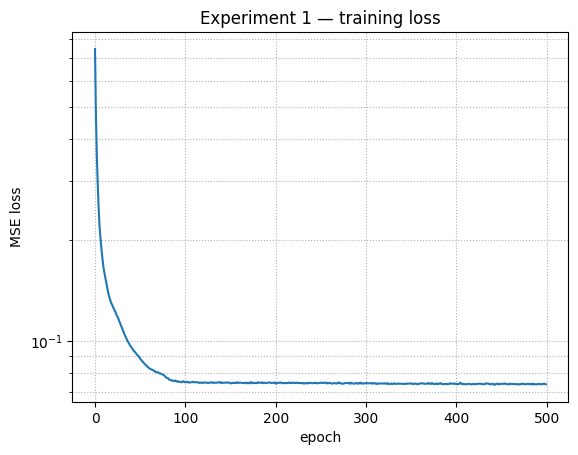

In [ ]:
EPOCHS_EXP1 = int(os.environ.get("EPOCHS_EXP1", 500))  # paper: ~5000

optimizer1 = optim.Adam(qnn_exp1.parameters(), lr=1e-2)
mse = nn.MSELoss()

history_exp1 = []
qnn_exp1.train()
for epoch in range(EPOCHS_EXP1):
    epoch_loss = 0.0
    n_batches = 0
    for t_b, x_b, y_b, z_b, phi_b, lam_b, psi_b in dataloader:
        optimizer1.zero_grad()
        inputs = {"t": t_b, "x": x_b, "y": y_b, "z": z_b}
        pred = qnn_exp1(inputs).squeeze(-1)
        loss = mse(pred, psi_b)
        loss.backward()
        optimizer1.step()
        epoch_loss += loss.item()
        n_batches += 1
    avg = epoch_loss / max(1, n_batches)
    history_exp1.append(avg)
    if epoch % max(1, EPOCHS_EXP1 // 20) == 0 or epoch == EPOCHS_EXP1 - 1:
        print(f"[Exp1] epoch {epoch:4d}/{EPOCHS_EXP1} loss = {avg:.4e}")

plt.figure()
plt.semilogy(history_exp1)
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.title("Experiment 1 — training loss")
plt.grid(True, which="both", ls=":")
plt.show()

## 10 — Reproduce Figure 3: predicted ψ map

We freeze the trained QNN, sample it on the lat–lon grid for the **first time
slice** and plot true vs predicted ψ side by side.


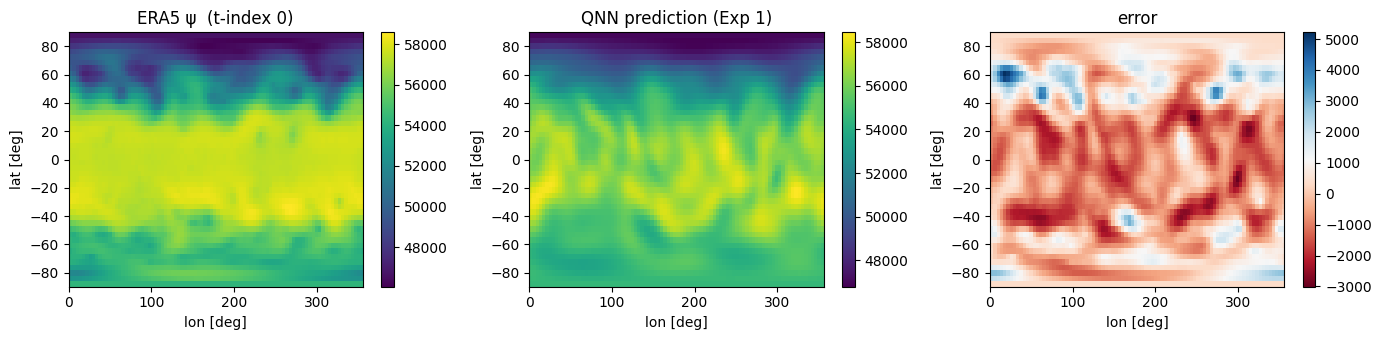

In [ ]:
def predict_psi_field(qnn, dataset, time_index=0):
    """Run the QNN on every (lat, lon) at a given time index, returning a 2-D map."""
    T, nlat, nlon = dataset.shape
    feats = dataset.feats.view(T, nlat, nlon, 6)
    f = feats[time_index].reshape(-1, 6)
    inputs = {"t": f[:, 0], "x": f[:, 1], "y": f[:, 2], "z": f[:, 3]}
    qnn.eval()
    with torch.no_grad():
        pred = qnn(inputs).squeeze(-1)
    pred = pred.detach().view(nlat, nlon).cpu().numpy()
    # De-standardise back to physical units
    return pred * dataset.targ_std + dataset.targ_mean

t_idx = 0
true_field = (dataset.targets.view(*dataset.shape)[t_idx].cpu().numpy()
              * dataset.targ_std + dataset.targ_mean)
pred_field = predict_psi_field(qnn_exp1, dataset, time_index=t_idx)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
im0 = ax[0].imshow(true_field, aspect="auto",
                   extent=[lon_deg.min(), lon_deg.max(), lat_deg.min(), lat_deg.max()],
                   origin="lower")
ax[0].set_title(f"ERA5 ψ  (t-index {t_idx})"); plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(pred_field, aspect="auto",
                   extent=[lon_deg.min(), lon_deg.max(), lat_deg.min(), lat_deg.max()],
                   origin="lower")
ax[1].set_title("QNN prediction (Exp 1)"); plt.colorbar(im1, ax=ax[1])
err = pred_field - true_field
im2 = ax[2].imshow(err, aspect="auto", cmap="RdBu",
                   extent=[lon_deg.min(), lon_deg.max(), lat_deg.min(), lat_deg.max()],
                   origin="lower")
ax[2].set_title("error"); plt.colorbar(im2, ax=ax[2])
for a in ax: a.set_xlabel("lon [deg]"); a.set_ylabel("lat [deg]")
plt.tight_layout(); plt.show()


In [ ]:
# --- Évaluation : MRE et PPMC (métriques du papier) ---
def mre(pred, true):
    return np.abs(pred - true) / (np.abs(true) + 1e-12)

def ppmc(pred, true):
    return np.corrcoef(pred.ravel(), true.ravel())[0, 1]

mre_map = mre(pred_field, true_field)
print(f"MRE médian  : {np.median(mre_map):.4f}")
print(f"MRE moyen   : {np.mean(mre_map):.4f}")
print(f"PPMC        : {ppmc(pred_field, true_field):.4f}")

MRE médian  : 0.0143
MRE moyen   : 0.0169
PPMC        : 0.9547


In [ ]:
# --- Graphe : prédiction vs vérité (visualise PPMC / MRE) ---
plt.figure(figsize=(5, 5))
tv = true_field.ravel()
pv = pred_field.ravel()
plt.scatter(tv, pv, s=8, alpha=0.5)
lims = [min(tv.min(), pv.min()), max(tv.max(), pv.max())]
plt.plot(lims, lims, "r--", lw=1, label="y = x (perfect prediction)")
plt.xlabel("ψ ERA5 (Truth)")
plt.ylabel("ψ prédit (QNN, Exp 1)")
plt.title(f"Exp 1 — predict vs truth\n"
          f"PPMC = {ppmc(pred_field, true_field):.4f}   "
          f"MRE median = {np.median(mre_map):.4f}")
plt.legend(); plt.grid(True, ls=":")
plt.tight_layout(); plt.show()

NameError: name 'plt' is not defined

## 11 — Build the QNN for **Experiment 2** (DQC, N = 4, ℓ = 4)


In [ ]:
N_EXP2 = 4

qnn_dqc = QNN.from_configs(
    register=N_EXP2,
    obs_config=obs_config,
    fm_config=fm_config,
    ansatz_config=ansatz_config_exp2,
    backend=BackendName.PYQTORCH,
    diff_mode=DiffMode.AD,
)

n_params2 = sum(p.numel() for p in qnn_dqc.parameters() if p.requires_grad)
print(f"DQC QNN  —  qubits: {N_EXP2}, depth: {DEPTH_EXP2}, "
      f"trainable params: {n_params2}")


DQC QNN  —  qubits: 4, depth: 4, trainable params: 84


## 12 — Physics loss: BVE residual on the sphere

Spherical Laplacian (φ = colatitude):

$$\zeta = \nabla^2\psi = \partial_\phi^2\psi + \cot\phi\,\partial_\phi\psi
+ \frac{1}{\sin^2\phi}\,\partial_\lambda^2\psi$$

Coriolis term `f = 2Ω cos φ` (φ = colatitude ⇒ `cos φ = sin(lat)`).
Absolute vorticity `η = ζ + f`.  BVE:

$$\partial_t \zeta + \frac{1}{\sin\phi}\big(\partial_\lambda\psi\,\partial_\phi\eta
   - \partial_\phi\psi\,\partial_\lambda\eta\big) = 0.$$

We compute every derivative through `torch.autograd.grad` — *that* is what
makes the circuit a *Differentiable* QC.  The leaves of the graph are the
spherical coordinates `(t, φ, λ)`; the `(x, y, z)` mapping is applied **inside**
the loss so the chain-rule flows through it automatically.


In [ ]:
OMEGA_EARTH = 7.292e-5  # rad / s

def compute_bve_residual_loss(qnn, t, phi, lam, omega=OMEGA_EARTH):
    """All inputs are 1-D tensors with requires_grad=True."""
    # Cartesian inputs derived from spherical leaves so AD chain-rules through.
    x = torch.sin(phi) * torch.cos(lam)
    y = torch.sin(phi) * torch.sin(lam)
    z = torch.cos(phi)
    psi = qnn({"t": t, "x": x, "y": y, "z": z}).squeeze(-1)

    ones = torch.ones_like(psi)

    # First derivatives w.r.t. spherical coords
    dpsi_dphi, dpsi_dlam, dpsi_dt = torch.autograd.grad(
        psi, (phi, lam, t), grad_outputs=ones, create_graph=True
    )

    # Second derivatives needed for the spherical Laplacian
    d2psi_dphi2 = torch.autograd.grad(
        dpsi_dphi, phi, grad_outputs=torch.ones_like(dpsi_dphi),
        create_graph=True
    )[0]
    d2psi_dlam2 = torch.autograd.grad(
        dpsi_dlam, lam, grad_outputs=torch.ones_like(dpsi_dlam),
        create_graph=True
    )[0]

    sin_phi = torch.sin(phi)
    cos_phi = torch.cos(phi)
    eps = 1e-4
    safe_sin = torch.where(sin_phi.abs() < eps,
                           torch.full_like(sin_phi, eps), sin_phi)

    zeta = d2psi_dphi2 + (cos_phi / safe_sin) * dpsi_dphi \
           + (1.0 / safe_sin ** 2) * d2psi_dlam2

    # Coriolis: φ is colatitude, so cos(φ) = sin(latitude)
    f_coriolis = 2.0 * omega * cos_phi
    eta = zeta + f_coriolis

    dzeta_dt = torch.autograd.grad(
        zeta, t, grad_outputs=torch.ones_like(zeta), create_graph=True
    )[0]
    deta_dphi = torch.autograd.grad(
        eta, phi, grad_outputs=torch.ones_like(eta), create_graph=True
    )[0]
    deta_dlam = torch.autograd.grad(
        eta, lam, grad_outputs=torch.ones_like(eta), create_graph=True
    )[0]

    jacobian = (1.0 / safe_sin) * (dpsi_dlam * deta_dphi - dpsi_dphi * deta_dlam)
    residual = dzeta_dt + jacobian
    return torch.mean(residual**2) / (residual.detach().abs().mean()**2 + 1e-12)

## 13 — Train Experiment 2 (DQC / Physics-Informed)

Total loss

$$\mathcal L = \alpha_1\,\text{MSE}(\hat\psi,\psi_{\text{ERA5}}) + \alpha_4\,\text{MSE}(\text{BVE residual})$$

with the paper's weights `α₁ = 1`, `α₄ = 0.1`.  Here α₄ is reduced to 1e-4 to keep the physics term from dominating the data term Collocation points for the
physics term are sampled randomly inside the domain at each step.


[DQC] epoch     0  total=1.029e+00  data=1.029e+00  phys=2.055e+00
[DQC] epoch    15  total=5.831e-01  data=5.829e-01  phys=2.084e+00
[DQC] epoch    30  total=4.176e-01  data=4.174e-01  phys=1.848e+00
[DQC] epoch    45  total=3.536e-01  data=3.534e-01  phys=2.074e+00
[DQC] epoch    60  total=2.858e-01  data=2.856e-01  phys=2.069e+00
[DQC] epoch    75  total=2.595e-01  data=2.593e-01  phys=2.201e+00
[DQC] epoch    90  total=2.343e-01  data=2.341e-01  phys=2.064e+00
[DQC] epoch   105  total=2.389e-01  data=2.387e-01  phys=1.916e+00
[DQC] epoch   120  total=2.098e-01  data=2.096e-01  phys=1.904e+00
[DQC] epoch   135  total=1.985e-01  data=1.983e-01  phys=2.026e+00
[DQC] epoch   150  total=1.755e-01  data=1.752e-01  phys=2.146e+00
[DQC] epoch   165  total=1.716e-01  data=1.714e-01  phys=2.326e+00
[DQC] epoch   180  total=1.507e-01  data=1.505e-01  phys=2.541e+00
[DQC] epoch   195  total=1.477e-01  data=1.475e-01  phys=2.130e+00
[DQC] epoch   210  total=1.407e-01  data=1.405e-01  phys=2.170

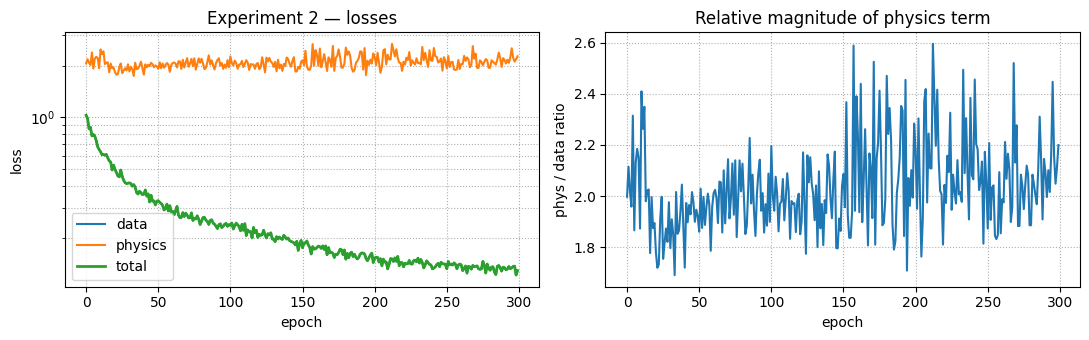

In [ ]:
ALPHA1 = 1.0
ALPHA4 = 1e-4
EPOCHS_EXP2 = int(os.environ.get("EPOCHS_EXP2", 500))   # paper: ~30000
N_COLLOC = 256

optimizer2 = optim.Adam(qnn_dqc.parameters(), lr=1e-2)

history_data, history_phys, history_total = [], [], []

# Sample collocation points away from the poles to avoid 1/sinφ blow-ups.
def sample_collocation(n):
    t = torch.rand(n) * 1.0
    phi = torch.empty(n).uniform_(np.pi * 0.10, np.pi * 0.90)
    lam = torch.empty(n).uniform_(0.0, 2 * np.pi)
    t.requires_grad_(True); phi.requires_grad_(True); lam.requires_grad_(True)
    return t, phi, lam

qnn_dqc.train()
data_iter = iter(dataloader)

for epoch in range(EPOCHS_EXP2):
    # ---- data batch ----
    try:
        t_b, x_b, y_b, z_b, phi_b, lam_b, psi_b = next(data_iter)
    except StopIteration:
        data_iter = iter(dataloader)
        t_b, x_b, y_b, z_b, phi_b, lam_b, psi_b = next(data_iter)

    optimizer2.zero_grad()

    pred = qnn_dqc({"t": t_b, "x": x_b, "y": y_b, "z": z_b}).squeeze(-1)
    loss_data = mse(pred, psi_b)

    # ---- physics batch ----
    t_c, phi_c, lam_c = sample_collocation(N_COLLOC)
    loss_phys = compute_bve_residual_loss(qnn_dqc, t_c, phi_c, lam_c)

    loss = ALPHA1 * loss_data + ALPHA4 * loss_phys
    loss.backward()
    optimizer2.step()

    history_data.append(loss_data.item())
    history_phys.append(loss_phys.item())
    history_total.append(loss.item())

    if epoch % max(1, EPOCHS_EXP2 // 20) == 0 or epoch == EPOCHS_EXP2 - 1:
        print(f"[DQC] epoch {epoch:5d}  total={loss.item():.3e}  "
              f"data={loss_data.item():.3e}  phys={loss_phys.item():.3e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].semilogy(history_data, label="data")
ax[0].semilogy(history_phys, label="physics")
ax[0].semilogy(history_total, label="total", lw=2)
ax[0].legend(); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_title("Experiment 2 — losses"); ax[0].grid(True, which="both", ls=":")

ax[1].plot(np.array(history_phys) / max(np.array(history_data) + 1e-12, key=lambda v: 1.0))
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("phys / data ratio")
ax[1].set_title("Relative magnitude of physics term"); ax[1].grid(True, ls=":")
plt.tight_layout(); plt.show()


## 14 — Reproduce Figures 4 & 5

* **Fig 4** — DQC prediction vs ERA5 ψ at a few time slices.
* **Fig 5** — pointwise BVE residual map (smaller residual ⇒ better physics
  consistency).


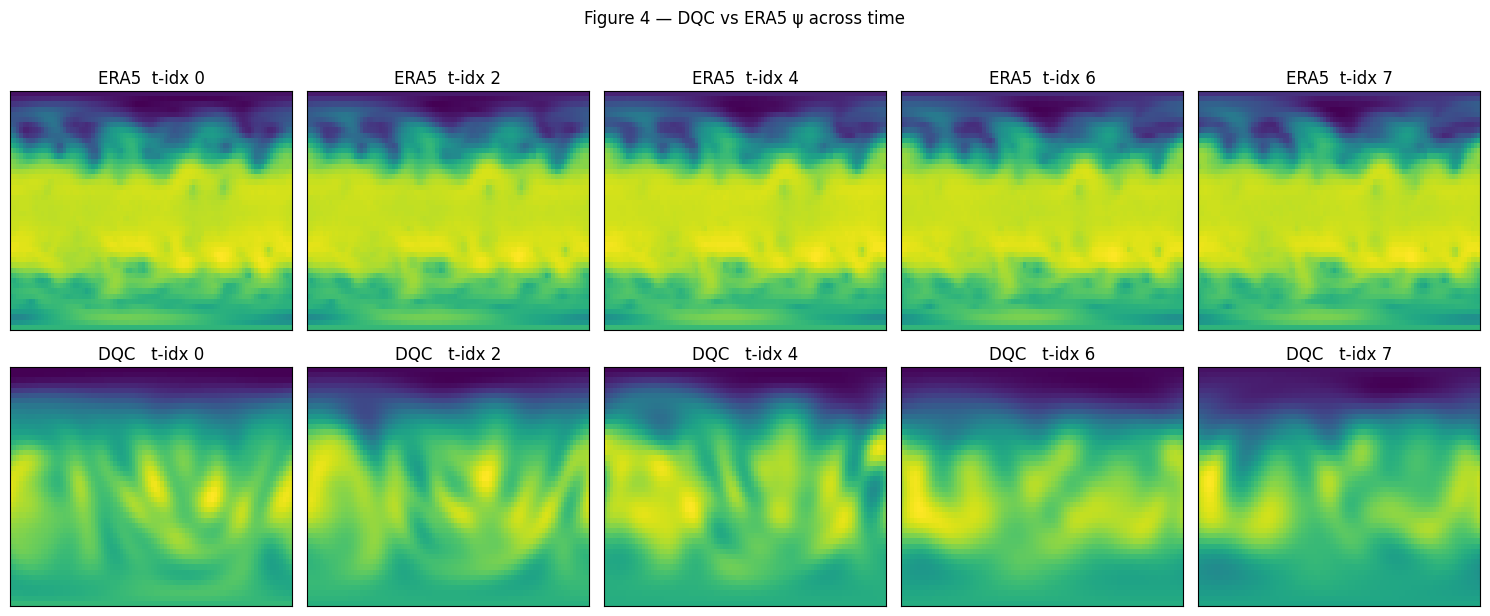

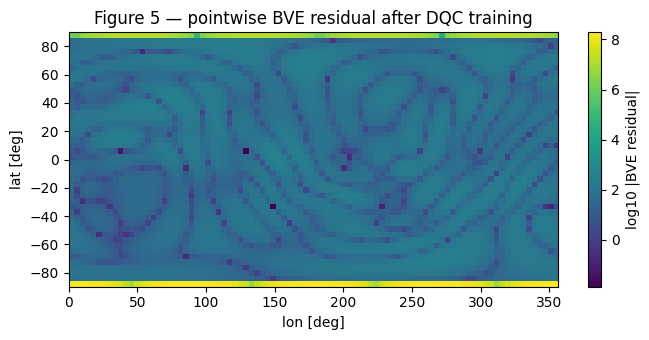

In [ ]:
# --- Figure 4: DQC predictions vs truth at several time indices ---
T = dataset.shape[0]
time_indices = [0, T // 4, T // 2, 3 * T // 4, T - 1] if T >= 4 else list(range(T))

fig, axes = plt.subplots(2, len(time_indices), figsize=(3 * len(time_indices), 6))
for col, ti in enumerate(time_indices):
    truth = (dataset.targets.view(*dataset.shape)[ti].cpu().numpy()
             * dataset.targ_std + dataset.targ_mean)
    pred = predict_psi_field(qnn_dqc, dataset, time_index=ti)
    axes[0, col].imshow(truth, origin="lower", aspect="auto")
    axes[0, col].set_title(f"ERA5  t-idx {ti}")
    axes[1, col].imshow(pred, origin="lower", aspect="auto")
    axes[1, col].set_title(f"DQC   t-idx {ti}")
    for r in (0, 1):
        axes[r, col].set_xticks([]); axes[r, col].set_yticks([])
plt.suptitle("Figure 4 — DQC vs ERA5 ψ across time", y=1.02)
plt.tight_layout(); plt.show()

# --- Figure 5: BVE residual map ---
nlat, nlon = dataset.shape[1], dataset.shape[2]
lat_rad = np.deg2rad(lat_deg)
lon_rad = np.deg2rad(lon_deg)
LAT, LON = np.meshgrid(lat_rad, lon_rad, indexing="ij")
PHI_grid = np.pi / 2.0 - LAT
LAM_grid = LON

t_eval = torch.full((nlat * nlon,), 0.0, requires_grad=True)
phi_eval = torch.tensor(PHI_grid.reshape(-1), requires_grad=True)
lam_eval = torch.tensor(LAM_grid.reshape(-1), requires_grad=True)

# Compute residual *pointwise* — reuse the loss function but keep the per-point
# squared residual instead of its mean.
def pointwise_residual(qnn, t, phi, lam, omega=OMEGA_EARTH):
    x = torch.sin(phi) * torch.cos(lam)
    y = torch.sin(phi) * torch.sin(lam)
    z = torch.cos(phi)
    psi = qnn({"t": t, "x": x, "y": y, "z": z}).squeeze(-1)
    ones = torch.ones_like(psi)
    dpsi_dphi, dpsi_dlam, dpsi_dt = torch.autograd.grad(
        psi, (phi, lam, t), grad_outputs=ones, create_graph=True
    )
    d2psi_dphi2 = torch.autograd.grad(dpsi_dphi, phi,
        grad_outputs=torch.ones_like(dpsi_dphi), create_graph=True)[0]
    d2psi_dlam2 = torch.autograd.grad(dpsi_dlam, lam,
        grad_outputs=torch.ones_like(dpsi_dlam), create_graph=True)[0]
    sp, cp = torch.sin(phi), torch.cos(phi)
    eps = 1e-4
    sp_safe = torch.where(sp.abs() < eps, torch.full_like(sp, eps), sp)
    zeta = d2psi_dphi2 + (cp / sp_safe) * dpsi_dphi + (1.0 / sp_safe ** 2) * d2psi_dlam2
    eta = zeta + 2.0 * omega * cp
    dzeta_dt = torch.autograd.grad(zeta, t, grad_outputs=torch.ones_like(zeta), create_graph=True)[0]
    deta_dphi = torch.autograd.grad(eta, phi, grad_outputs=torch.ones_like(eta), create_graph=True)[0]
    deta_dlam = torch.autograd.grad(eta, lam, grad_outputs=torch.ones_like(eta), create_graph=True)[0]
    return dzeta_dt + (1.0 / sp_safe) * (dpsi_dlam * deta_dphi - dpsi_dphi * deta_dlam)

res = pointwise_residual(qnn_dqc, t_eval, phi_eval, lam_eval).detach().cpu().numpy()
res_map = res.reshape(nlat, nlon)

plt.figure(figsize=(7, 3.5))
plt.imshow(np.log10(np.abs(res_map) + 1e-20),
           extent=[lon_deg.min(), lon_deg.max(), lat_deg.min(), lat_deg.max()],
           origin="lower", aspect="auto", cmap="viridis")
plt.colorbar(label="log10 |BVE residual|")
plt.title("Figure 5 — pointwise BVE residual after DQC training")
plt.xlabel("lon [deg]"); plt.ylabel("lat [deg]")
plt.tight_layout(); plt.show()


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 73.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


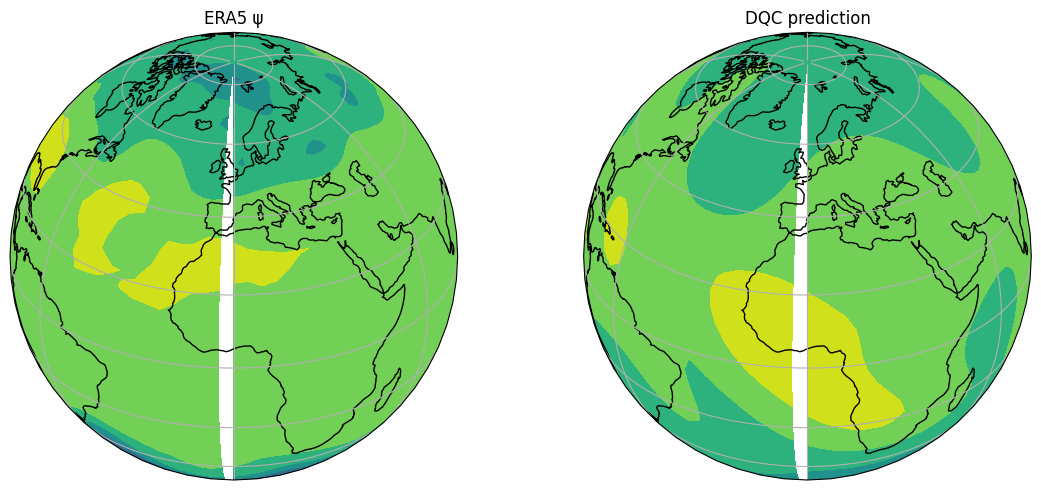

In [ ]:
import cartopy.crs as ccrs

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Orthographic(0, 30))
ax1.coastlines()
ax1.gridlines()
truth = (dataset.targets.view(*dataset.shape)[0].cpu().numpy()
         * dataset.targ_std + dataset.targ_mean)
ax1.contourf(lon_deg, lat_deg, truth, transform=ccrs.PlateCarree(), cmap='viridis')
ax1.set_title("ERA5 ψ")

ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.Orthographic(0, 30))
ax2.coastlines()
ax2.gridlines()
pred = predict_psi_field(qnn_dqc, dataset, time_index=0)
ax2.contourf(lon_deg, lat_deg, pred, transform=ccrs.PlateCarree(), cmap='viridis')
ax2.set_title("DQC prediction")
plt.tight_layout(); plt.show()